# Notebook 09: Spatial smoothing

Smoothing replaces each row's feature value with a Gaussian-weighted average over its nearest spatial neighbors, suppressing block-level noise while preserving regional structure. This is Nadaraya-Watson kernel regression truncated to the nearest neighbors for tractability. Only feature columns are smoothed, never the target.

We compare two ways of using the smoothed values: adding them alongside the originals, which lets the model weigh local context against block-level detail, and replacing the originals, which assumes the block-level detail is mostly noise.

## 1. Notebook set-up

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

sys.path.insert(0, str(Path.cwd().resolve().parent / 'src'))
import featurely as fl

from config import (
    DATA_DIR,
    PIPELINE_COLORS,
    PIPELINE_RESULTS_PATH,
    SMOOTH_FEATURES,
    SMOOTH_N_NEIGHBORS,
 )

## 2. Data loading

In [2]:
in_path = DATA_DIR / '08-clustering.csv'

if not in_path.exists():
    raise FileNotFoundError(
        (f'Missing required input file: {in_path}. Run 08-clustering.ipynb ' +
         'first to generate data/08-clustering.csv.')
    )

housing_df = pd.read_csv(in_path)
print(f'Loaded: {in_path}')

Loaded: /workspaces/featurely/data/08-clustering.csv


## 3. Smoothed feature candidates

The kernel bandwidth adapts to local point density: it defaults to the median distance to the farthest retained neighbor. The maps below compare the original and smoothed income surface; smoothing should preserve the coastal gradient while flattening isolated extreme blocks.

Using adaptive bandwidth: 0.0361 degrees


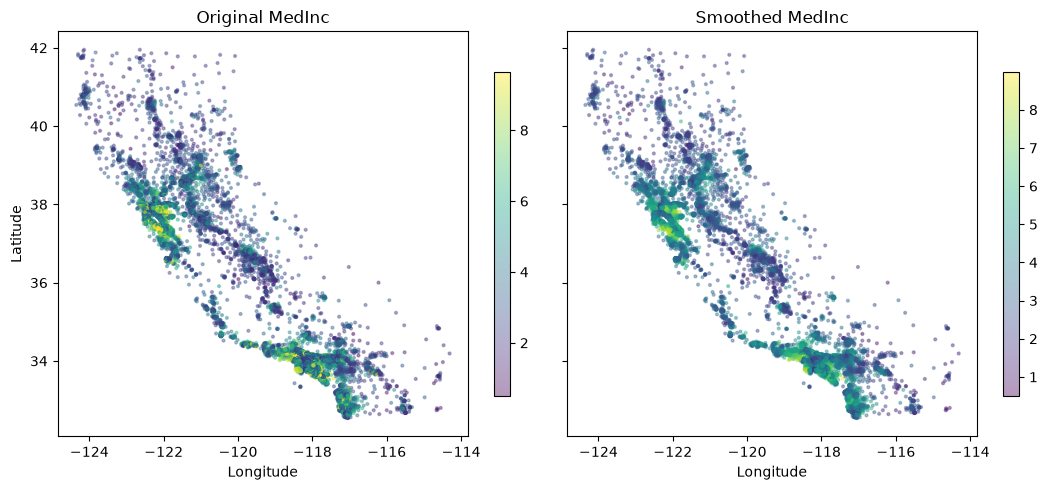

In [3]:
smoothed_df = fl.compute_spatial_smoothed(
    housing_df, SMOOTH_FEATURES, n_neighbors=SMOOTH_N_NEIGHBORS
 )

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

for ax, col, label in (
    (axes[0], 'MedInc', 'Original MedInc'),
    (axes[1], 'smooth_MedInc', 'Smoothed MedInc'),
):
    values = housing_df[col] if col in housing_df else smoothed_df[col]
    sc = ax.scatter(
        housing_df['Longitude'], housing_df['Latitude'],
        c=values, cmap='viridis', s=4, alpha=0.4
    )
    ax.set_title(label)
    ax.set_xlabel('Longitude')
    plt.colorbar(sc, ax=ax, shrink=0.8)

axes[0].set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## 4. Residual scan of smoothed candidates

Baseline R2 (in-sample): 0.7198

    smooth_MedInc: r = +0.1633,  p = 0.0000
  smooth_HouseAge: r = +0.0067,  p = 0.3390
  smooth_AveRooms: r = +0.0223,  p = 0.0013
  smooth_AveOccup: r = -0.1433,  p = 0.0000
smooth_Population: r = -0.0366,  p = 0.0000


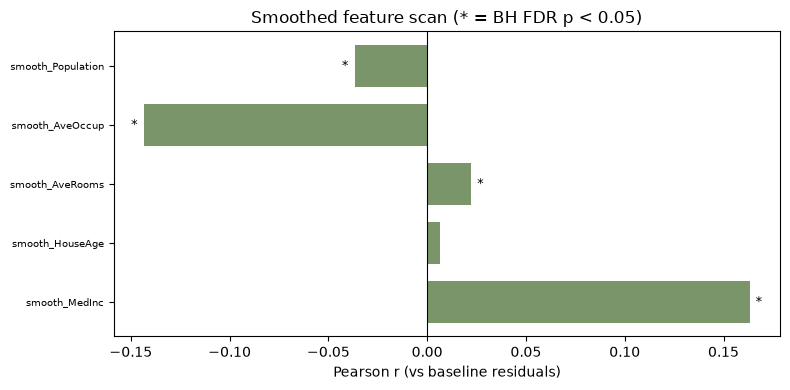

In [4]:
scan_results = fl.run_candidate_scan(housing_df, smoothed_df)

sig_dict = fl.plot_candidate_scan(
    scan_results,
    title='Smoothed feature scan (* = BH FDR p < 0.05)',
    color=PIPELINE_COLORS.get('+ smoothed', '#43682b'),
 )

## 5. Add versus replace comparison

Three configurations compete: keep the frame as-is, add the smoothed columns alongside the originals, or replace the originals with their smoothed versions. Paired t-tests with Holm-Bonferroni correction decide whether either change is a real improvement.

In [5]:
x_base = housing_df.drop('MedHouseVal', axis=1)
y = housing_df['MedHouseVal']

smoothing_sets = {
    'baseline': x_base,
    'add smoothed': pd.concat([x_base, smoothed_df], axis=1),
    'replace originals': pd.concat(
        [x_base.drop(columns=SMOOTH_FEATURES), smoothed_df], axis=1
    ),
}

cv_smoothing_results = {}

for label, x in smoothing_sets.items():
    scores = cross_val_score(LinearRegression(), x, y, cv=10, scoring='r2')
    cv_smoothing_results[label] = scores
    print(f'{label:>18}: mean R² = {scores.mean():.4f} ± {scores.std():.4f}')

          baseline: mean R² = 0.6199 ± 0.0851


      add smoothed: mean R² = 0.6810 ± 0.0777


 replace originals: mean R² = 0.6719 ± 0.0740


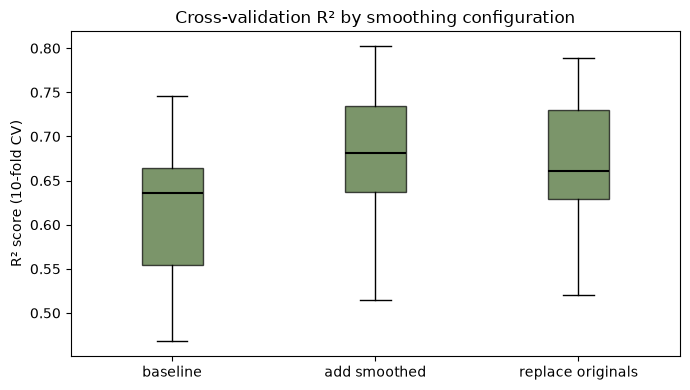


Paired t-tests vs baseline (Holm-Bonferroni; * = p_corr < 0.05):
  baseline vs       add smoothed: t = -6.9824,  p_raw = 0.0001,  p_corr = 0.0001 *
  baseline vs  replace originals: t = -5.2607,  p_raw = 0.0005,  p_corr = 0.0005 *


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

bp = ax.boxplot(
    cv_smoothing_results.values(),
    tick_labels=list(cv_smoothing_results.keys()),
    patch_artist=True
)

for patch in bp['boxes']:
    patch.set_facecolor(PIPELINE_COLORS.get('+ smoothed', '#43682b'))
    patch.set_alpha(0.7)

for median in bp['medians']:
    median.set(color='black', linewidth=1.5)

ax.set_title('Cross-validation R² by smoothing configuration')
ax.set_ylabel('R² score (10-fold CV)')
plt.tight_layout()
plt.show()

baseline_scores = cv_smoothing_results['baseline']
paired_keys = [k for k in cv_smoothing_results if k != 'baseline']
t_stats, p_raws = [], []

for k in paired_keys:
    t_stat, p_raw = ttest_rel(baseline_scores, cv_smoothing_results[k])
    t_stats.append(t_stat)
    p_raws.append(p_raw)

reject, p_corrected, _, _ = multipletests(p_raws, alpha=0.05, method='holm')

print('\nPaired t-tests vs baseline (Holm-Bonferroni; * = p_corr < 0.05):')
improved = {}

for k, t_stat, p_raw, p_corr, rej in zip(paired_keys, t_stats, p_raws, p_corrected, reject):
    marker = ' *' if rej else ''
    print(f'  baseline vs {k:>18}: t = {t_stat:+.4f},  p_raw = {p_raw:.4f},  p_corr = {p_corr:.4f}{marker}')
    improved[k] = bool(rej) and cv_smoothing_results[k].mean() > baseline_scores.mean()

## 6. Apply winning configuration

The best significant configuration is applied to the frame; if neither add nor replace beats the baseline significantly, the features are left untouched.

In [7]:
best_label = None
best_mean = baseline_scores.mean()

for label in ('add smoothed', 'replace originals'):
    if improved.get(label, False) and cv_smoothing_results[label].mean() > best_mean:
        best_label = label
        best_mean = cv_smoothing_results[label].mean()

if best_label == 'add smoothed':
    housing_df = pd.concat([housing_df, smoothed_df], axis=1)
    print(f'Added {smoothed_df.shape[1]} smoothed feature(s) alongside originals.')

elif best_label == 'replace originals':
    housing_df = pd.concat(
        [housing_df.drop(columns=SMOOTH_FEATURES), smoothed_df], axis=1
    )
    print(f'Replaced {len(SMOOTH_FEATURES)} feature(s) with smoothed versions.')

else:
    print('No significant improvement from smoothing; no changes made.')

Added 5 smoothed feature(s) alongside originals.


## 7. Performance evaluation

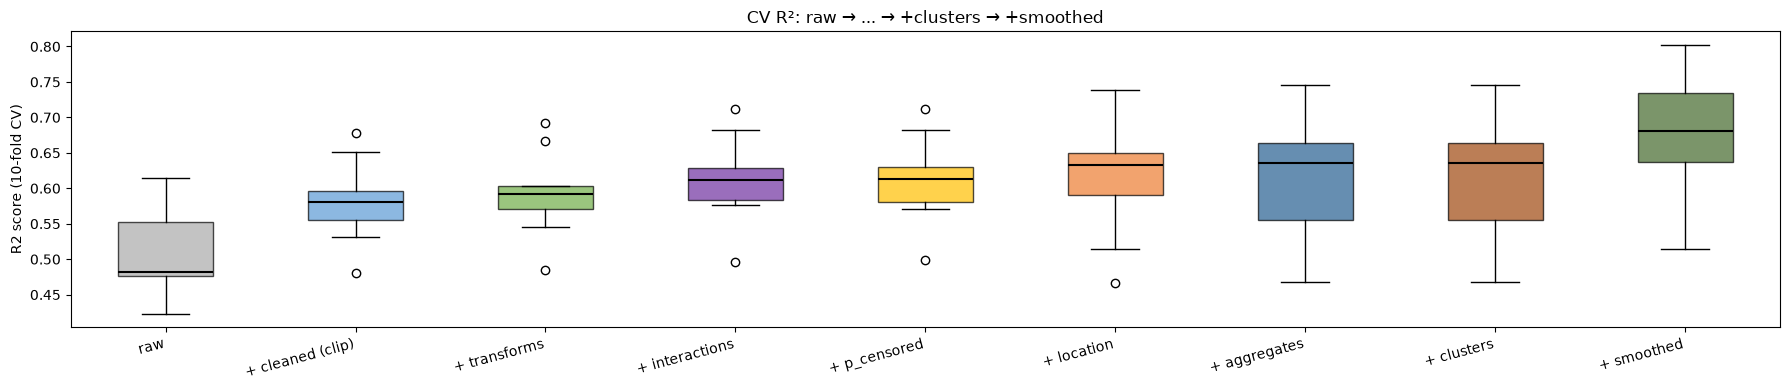

                      raw: mean R2 = 0.5110 ± 0.0593  (+0.00% vs raw)
         + cleaned (clip): mean R2 = 0.5811 ± 0.0536  (+13.71% vs raw)
             + transforms: mean R2 = 0.5923 ± 0.0551  (+15.90% vs raw)
           + interactions: mean R2 = 0.6122 ± 0.0561  (+19.81% vs raw)
             + p_censored: mean R2 = 0.6120 ± 0.0564  (+19.76% vs raw)
               + location: mean R2 = 0.6201 ± 0.0786  (+21.34% vs raw)
             + aggregates: mean R2 = 0.6199 ± 0.0851  (+21.31% vs raw)
               + clusters: mean R2 = 0.6199 ± 0.0851  (+21.31% vs raw)
               + smoothed: mean R2 = 0.6810 ± 0.0777  (+33.26% vs raw)


In [8]:
results_df = fl.add_pipeline_step(
    None,
    '+ smoothed',
    housing_df.drop('MedHouseVal', axis=1),
    housing_df['MedHouseVal'],
    color=PIPELINE_COLORS.get('+ smoothed', '#43682b'),
    results_path=PIPELINE_RESULTS_PATH,
 )

fl.plot_pipeline_steps(
    results_df,
    title='CV R²: raw → ... → +clusters → +smoothed',
    results_path=PIPELINE_RESULTS_PATH,
 )

## 8. Save output

In [9]:
out_path = DATA_DIR / '09-smoothing.csv'
housing_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Saved: /workspaces/featurely/data/09-smoothing.csv
